
# EDA: NRC/Groeneveld 24,579-Point CHF Database (`nrc_groeneveld_24579pt_chf_database.csv`)

The raw experimental database underlying the 2006 Groeneveld CHF Look-Up
Table: tube diameter, heated length, pressure, mass flux, outlet quality,
inlet subcooling/temperature and measured CHF, compiled from many source
studies (`Reference ID`). This is by far the largest raw file in the corpus
(24,579 data rows) — plots below use transparency/hexbin-style styling and a
top-N view of `Reference ID` rather than a full one-hot breakdown.

## 1. Load Data

Row 2 of the raw CSV is a units header (`m`, `kPa`, `kg/m^2/s`, ...), not
data, and is skipped on load.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/nrc_groeneveld_chf_database")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SLUG = "nrc_groeneveld_chf_database"
SLUG_TITLE = "NRC/Groeneveld 24,579-pt CHF Database"

raw = pd.read_csv(DATA_DIR / "nrc_groeneveld_24579pt_chf_database.csv",
                   encoding="utf-8-sig", skiprows=[1])

numeric_like = ["Number", "Tube Diameter", "Heated Length", "Pressure", "Mass Flux",
                 "Outlet Quality", "Inlet Subcooling", "Inlet Temperature", "CHF"]
for c in numeric_like:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw["CHF Result"] = pd.to_numeric(raw["CHF Result"], errors="coerce")

print("Rows where 'CHF Result' is populated (data-quality artifact; expected ~0):",
      raw["CHF Result"].notna().sum(), "/", len(raw))

df = raw.drop(columns=["CHF Result"])

NUMERIC_COLS = ["Tube Diameter", "Heated Length", "Pressure", "Mass Flux",
                 "Outlet Quality", "Inlet Subcooling", "Inlet Temperature", "CHF"]
CATEGORICAL_COLS = ["Reference ID"]
TARGET_COL = "CHF"

df.head()

Rows where 'CHF Result' is populated (data-quality artifact; expected ~0): 0 / 24579


,Number,Reference ID,Tube Diameter,Heated Length,Pressure,Mass Flux,Outlet Quality,Inlet Subcooling,Inlet Temperature,CHF
0,1,1,0.004,0.396,100.0,77.5,0.84,317.0,23.94,442.0
1,2,1,0.004,0.396,100.0,142.7,0.79,317.0,23.94,757.0
2,3,1,0.004,0.396,100.0,203.9,0.70,317.0,23.94,978.0
3,4,1,0.004,0.396,100.0,271.8,0.73,317.0,23.94,1325.0
4,5,1,0.004,0.396,100.0,421.3,0.62,317.0,23.94,1798.0


## 2. Data Quality

In [2]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (24579, 10)

Dtypes:
Number                 int64
Reference ID           int64
Tube Diameter        float64
Heated Length        float64
Pressure             float64
Mass Flux            float64
Outlet Quality       float64
Inlet Subcooling     float64
Inlet Temperature    float64
CHF                  float64
dtype: object

Missing values per column:
None

Duplicate rows: 0


## 3. Descriptive Statistics

In [3]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary.to_csv(OUT_DIR / "summary_stats.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Tube Diameter,24579.0,0.008931,0.002484,0.002,0.00787,0.00811,0.01001,0.016
Heated Length,24579.0,2.625391,2.043560,0.050,1.00000,2.00000,3.65800,20.000
Pressure,24579.0,9681.141129,5604.558604,100.000,5171.00000,9800.00000,14000.00000,20000.000
Mass Flux,24579.0,2009.776272,1511.230089,8.200,985.00000,1597.00000,2772.00000,7964.000
Outlet Quality,24579.0,0.355832,0.272694,-0.497,0.15800,0.32900,0.53425,0.999
Inlet Subcooling,24579.0,471.735817,328.858923,-1211.000,208.00000,439.00000,688.00000,1644.000
Inlet Temperature,24579.0,196.431857,89.698694,5.890,119.29500,212.33000,268.49000,361.940
CHF,24579.0,1808.037168,1591.654248,50.000,750.00000,1424.00000,2333.00000,16339.300


## 4. Categorical Value Counts

In [4]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} (n_unique={df[col].nunique(dropna=True)}) ---")
    print(df[col].value_counts(dropna=False).head(15))
    print()

--- Reference ID (n_unique=60) ---
Reference ID
31    5252
39    2928
43    2401
34    1435
53    1250
13    1057
36     835
9      809
10     752
8      749
17     661
2      616
57     482
0      384
35     361
Name: count, dtype: int64



## 5. Univariate Distributions

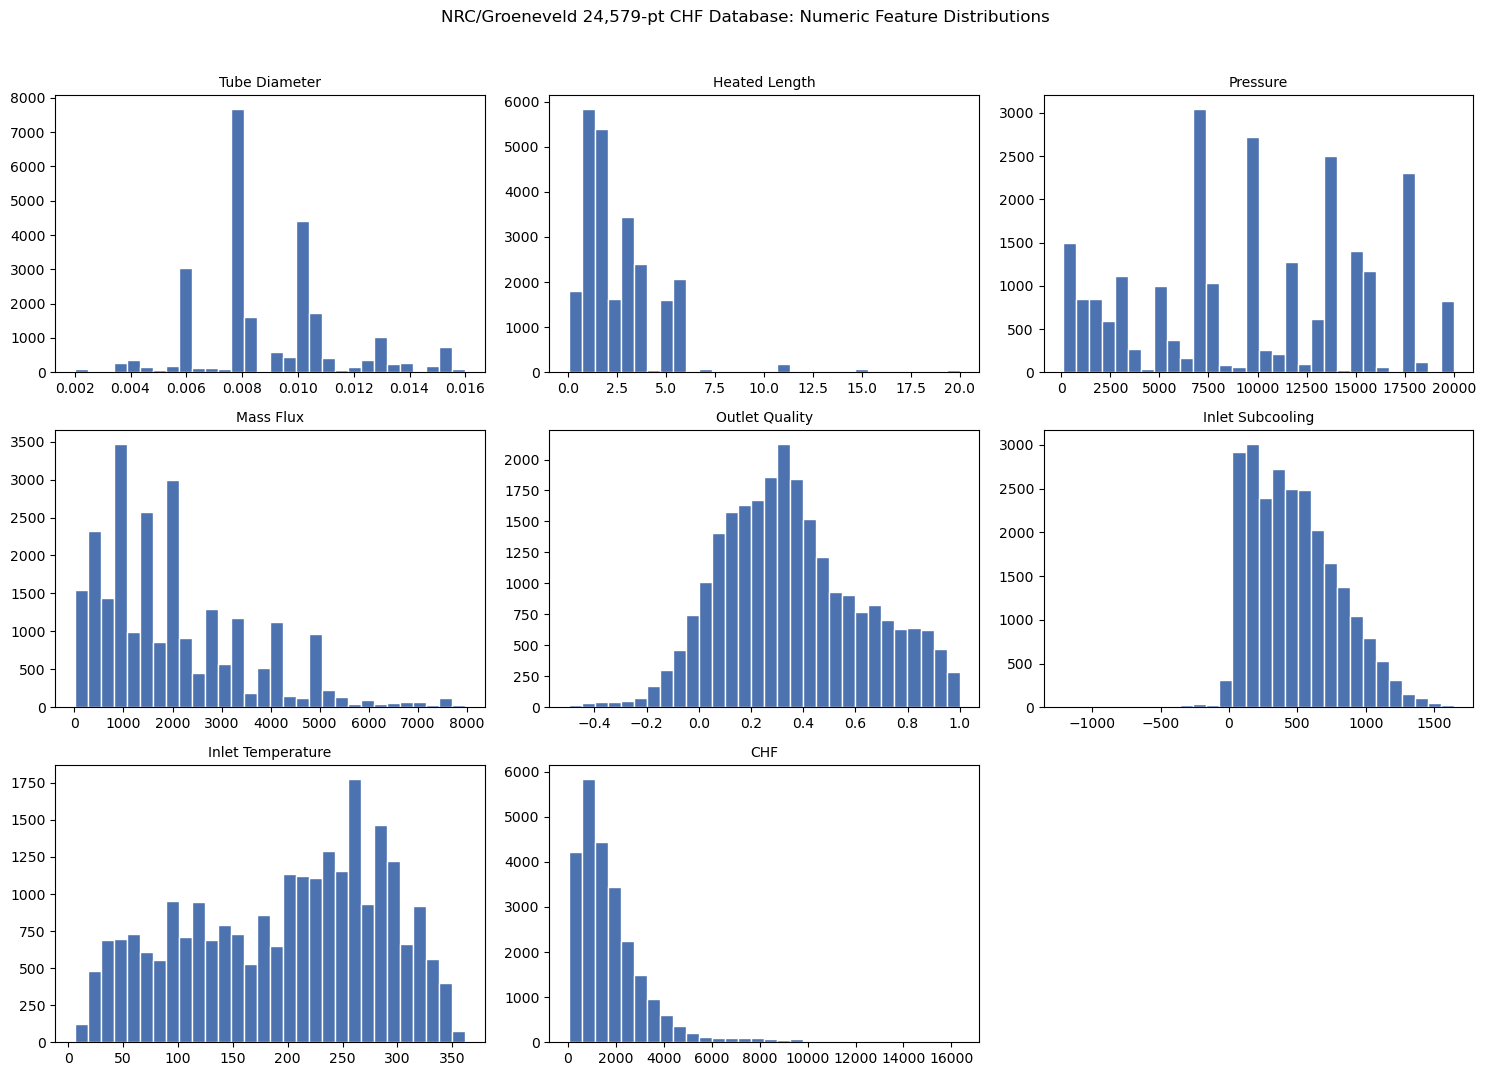

In [5]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: Numeric Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Scan (IQR, z-score)

In [6]:
iqr_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_rows.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s) if len(s) else np.nan,
    })
iqr_table = pd.DataFrame(iqr_rows).set_index("column")
iqr_table.to_csv(OUT_DIR / "iqr_outlier_summary.csv")
iqr_table

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
column,,,,,,,
Tube Diameter,0.00787,0.01001,0.00214,0.004660,0.013220,2275,9.255869
Heated Length,1.00000,3.65800,2.65800,-2.987000,7.645000,295,1.200212
Pressure,5171.00000,14000.00000,8829.00000,-8072.500000,27243.500000,0,0.000000
Mass Flux,985.00000,2772.00000,1787.00000,-1695.500000,5452.500000,622,2.530616
Outlet Quality,0.15800,0.53425,0.37625,-0.406375,1.098625,48,0.195289
Inlet Subcooling,208.00000,688.00000,480.00000,-512.000000,1408.000000,166,0.675373
Inlet Temperature,119.29500,268.49000,149.19500,-104.497500,492.282500,0,0.000000
CHF,750.00000,2333.00000,1583.00000,-1624.500000,4707.500000,1109,4.511982


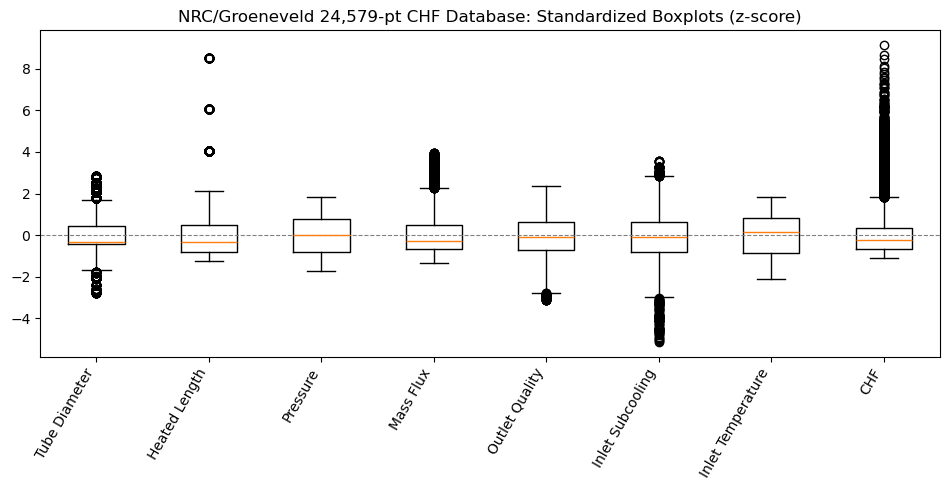

In [7]:
z = df[NUMERIC_COLS].apply(lambda s: (s - s.mean()) / s.std())
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(NUMERIC_COLS)), 5))
ax.boxplot([z[c].dropna() for c in NUMERIC_COLS])
ax.set_xticklabels(NUMERIC_COLS, rotation=60, ha="right")
ax.set_title(f"{SLUG_TITLE}: Standardized Boxplots (z-score)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplots_standardized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Structure

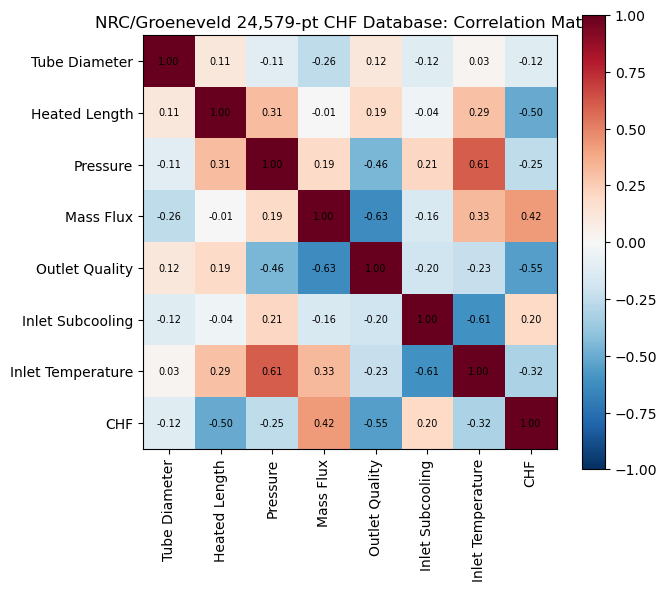

In [8]:
corr = df[NUMERIC_COLS].corr()
corr.to_csv(OUT_DIR / "correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(0.6 * len(NUMERIC_COLS) + 2, 0.6 * len(NUMERIC_COLS) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=90)
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title(f"{SLUG_TITLE}: Correlation Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Target vs. Features

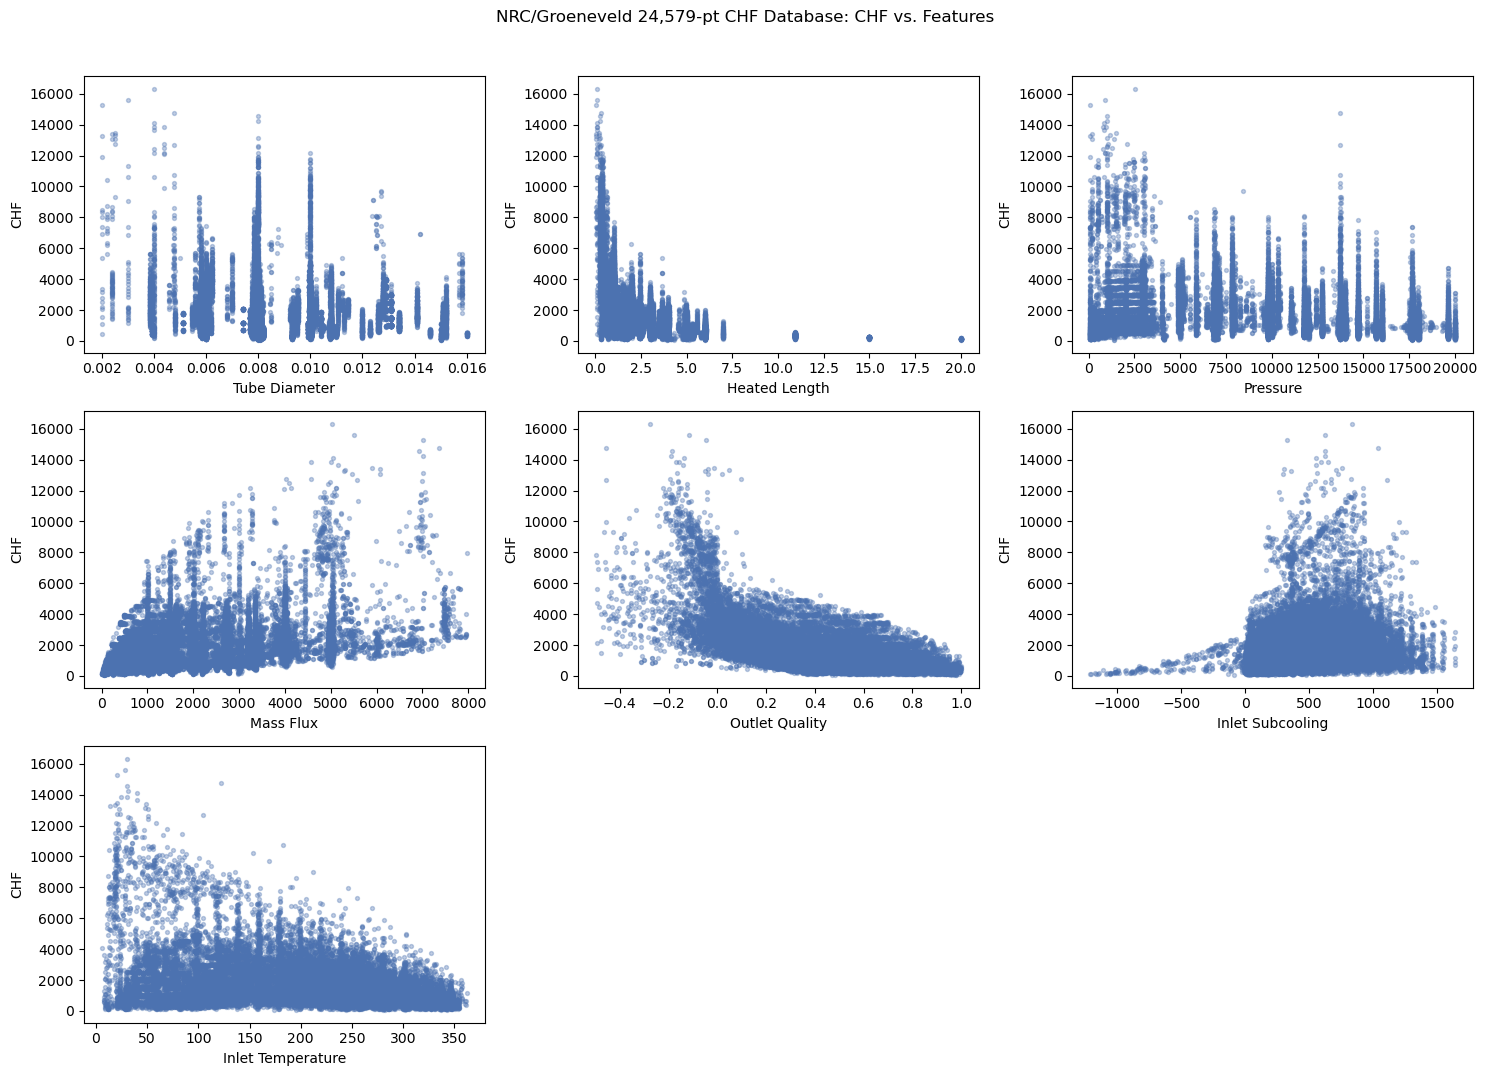

In [9]:
feature_cols = [c for c in NUMERIC_COLS if c != TARGET_COL]
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[TARGET_COL], s=8, alpha=0.35, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: {TARGET_COL} vs. Features", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Target by Category

In [10]:
cat_cols_plot = [c for c in CATEGORICAL_COLS
                 if 2 <= df[c].nunique(dropna=True) <= 15]
if cat_cols_plot:
    fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(6 * len(cat_cols_plot), 5), squeeze=False)
    axes = axes[0]
    for ax, col in zip(axes, cat_cols_plot):
        groups = [g[TARGET_COL].dropna().values for _, g in df.groupby(col)]
        labels = [str(k) for k, _ in df.groupby(col)]
        ax.boxplot(groups)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"{TARGET_COL} by {col}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.")

No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.


## 10. Coverage by Source Study (`Reference ID`)

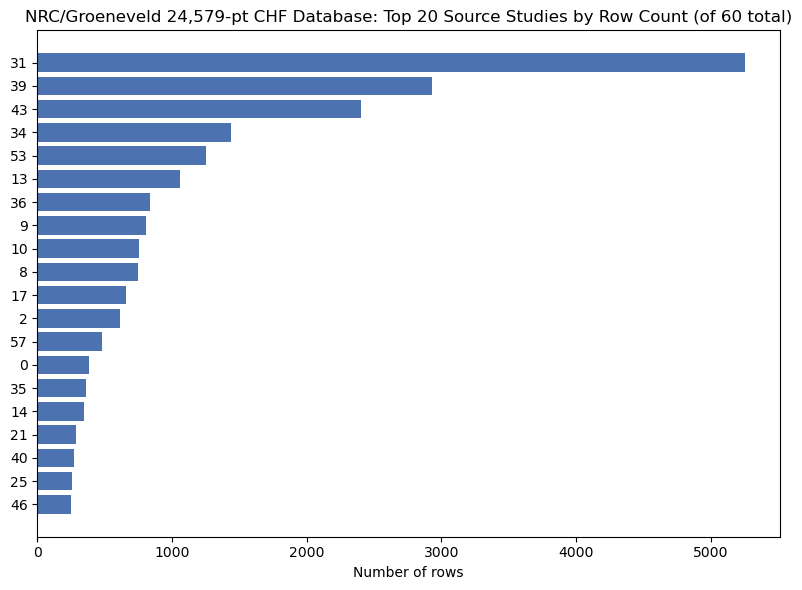

In [11]:
top_refs = df["Reference ID"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_refs.index.astype(str)[::-1], top_refs.values[::-1], color="#4C72B0")
ax.set_xlabel("Number of rows")
ax.set_title(f"{SLUG_TITLE}: Top 20 Source Studies by Row Count "
             f"(of {df['Reference ID'].nunique()} total)")
fig.tight_layout()
fig.savefig(FIG_DIR / "top_reference_ids.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Takeaways

- `CHF` (kW/m^2) is the target; `Pressure`, `Mass Flux`, `Outlet Quality`,
  `Tube Diameter` and `Heated Length` are the standard Groeneveld LUT
  predictors.
- `CHF Result` is essentially an empty column in this extract (a single stray
  unit-string value) — dropped from `df` as a data artifact rather than a
  real feature.
- `Reference ID` spans dozens of source studies at very uneven sample counts;
  treat it as provenance metadata rather than a modeling feature unless
  explicitly building a source-aware/leave-one-study-out validation scheme.
- Given the row count, scatter/histogram plots above use small markers and
  transparency (alpha) to stay legible — inspect `results/eda/nrc_groeneveld_chf_database/figures/`
  at full resolution for detail.
